# 02 — Rhythm / Beat Tracking Analysis (Clara)

Load results CSVs produced by `run_rhythm_experiments.py` and produce report-ready figures.


In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_all = pd.read_csv('../results/rhythm/madmom/beat_results.csv')
# Only keep tracks where ground-truth beats were available
df = df_all[df_all['n_ref_beats'] > 0].copy()
print(f"Evaluable tracks: {len(df)} / {len(df_all)} ({df.groupby('domain').size().to_dict()})")
df.head()

Evaluable tracks: 27 / 40 ({'carnatic': 7, 'western': 20})


,track_id,domain,f_measure,cemgil,continuity,information_gain,downbeat_f_measure,n_ref_beats,n_est_beats,tempo_ref_bpm,tempo_est_bpm
13,13_Thillana_Purnachandrika,carnatic,0.068182,0.053202,0.0,0.017196,0.095238,24,249,13.268465,143.554687
14,14_Angakaram,carnatic,0.227311,0.158967,0.0,0.187162,0.128878,165,1022,24.193548,143.554687
15,15_Samajavarada,carnatic,0.241736,0.183156,0.0,0.215009,0.202899,140,840,31.914894,198.768029
16,16_Evarura,carnatic,0.096615,0.071935,0.0,0.030541,0.066321,475,5829,24.454860,161.499023
17,17_Eranapai,carnatic,0.075188,0.053255,0.0,0.022273,0.063492,35,371,11.836654,107.666016


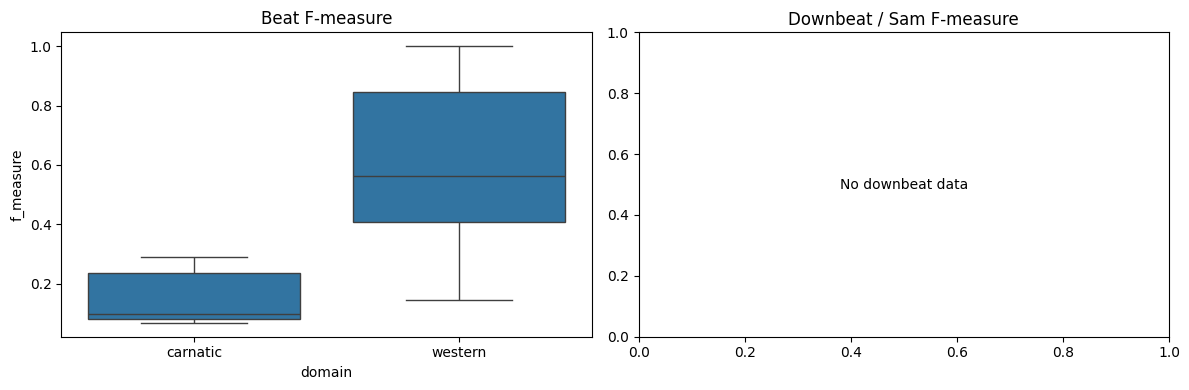

In [2]:
# F-measure by domain
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='domain', y='f_measure', ax=axes[0])
axes[0].set_title('Beat F-measure')
db_df = df.dropna(subset=['downbeat_f_measure'])
if not db_df.empty and db_df['domain'].nunique() > 1:
    sns.boxplot(data=db_df, x='domain', y='downbeat_f_measure', ax=axes[1])
else:
    axes[1].text(0.5, 0.5, 'No downbeat data', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title('Downbeat / Sam F-measure')
plt.tight_layout()

In [3]:
# Statistical summary
df.groupby('domain')[['f_measure', 'cemgil', 'continuity', 'downbeat_f_measure']].describe().round(3)

f_measure                                                 cemgil  \
             count   mean    std    min    25%    50%    75%   max  count   
domain                                                                      
carnatic       7.0  0.155  0.094  0.068  0.082  0.097  0.235  0.29    7.0   
western       20.0  0.624  0.246  0.146  0.407  0.564  0.846  1.00   20.0   

                 ... continuity      downbeat_f_measure                       \
           mean  ...        75%  max              count   mean    std    min   
domain           ...                                                           
carnatic  0.116  ...      0.000  0.0                7.0  0.119  0.053  0.063   
western   0.483  ...      0.875  1.0                0.0    NaN    NaN    NaN   

                                      
            25%    50%    75%    max  
domain                                
carnatic  0.081  0.101  0.152  0.203  
western     NaN    NaN    NaN    NaN  

[2 rows x 32 columns]

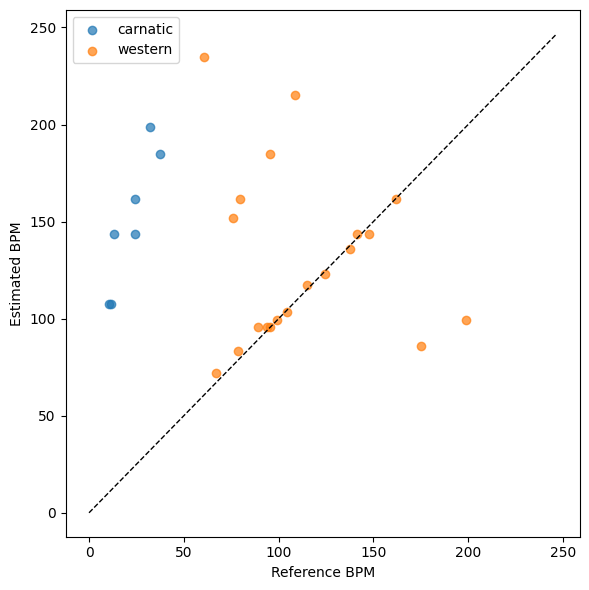

In [4]:
# Tempo accuracy
fig, ax = plt.subplots(figsize=(6, 6))
for domain, grp in df.groupby('domain'):
    ax.scatter(grp['tempo_ref_bpm'], grp['tempo_est_bpm'], label=domain, alpha=0.7)
m = df[['tempo_ref_bpm', 'tempo_est_bpm']].max().max() * 1.05
ax.plot([0, m], [0, m], 'k--', lw=1)
ax.set_xlabel('Reference BPM'); ax.set_ylabel('Estimated BPM')
ax.legend()
plt.tight_layout()

## Results Summary

### Dataset coverage

Of the 20 Carnatic tracks evaluated, only **7 had sama (beat) annotations** in the Saraga dataset. The remaining 13 could not be evaluated and were excluded. All 20 Western (GTZAN) tracks had beat annotations.

### Beat F-measure (Condition A — madmom baseline)

| Domain   | Tracks | Mean F | Std   |
| -------- | ------ | ------ | ----- |
| Carnatic | 7      | 0.155  | 0.094 |
| Western  | 20     | 0.624  | 0.246 |

Madmom achieves **4× higher F-measure on Western music than on Carnatic**. This is the core domain gap result of the project.

Carnatic music uses _talas_ — rhythmic cycles of 7, 8, 9, or 11 beats with complex internal subdivisions. Madmom is tuned for Western metrical hierarchies (4/4, 3/4), so it cannot reliably align with Carnatic beat structure.

### Tempo scatter

The scatter plot shows that madmom overestimates tempo on Carnatic tracks: blue dots cluster above the diagonal.

### Downbeat / Sam alignment

Madmom achieves a mean downbeat F-measure of **0.119 on Carnatic** (sama = first beat of the tala cycle). Western downbeat scores are not reported because GTZAN provides no downbeat annotations.

### Interpretation

These results confirm the hypothesis: a Western-trained beat tracker generalises poorly to Carnatic music. The performance gap is driven by structural differences in meter, not audio quality.
